# Wind Farm Yaw Control via PPO (Proximal Policy Optimization)

This notebook trains a PPO agent to maximize total power output by controlling the yaw angles of 3 turbines in the `Turb3_Row1_Floris` environment.

**Baselines to beat** (Scenario 2 - random wind conditions):
- Note: Sc.1 fixed-wind baselines (228/232) do not apply here; Sc.2 rewards vary with sampled wind conditions.
- WFCRL ([arXiv:2501.13592](https://arxiv.org/abs/2501.13592)), Table 7 - `Turb3_Row1_Floris` FLORIS, 200k steps:
  - **IPPO (trained Sc.2, eval Sc.2): 406.0 +/- 10.5** <- target to beat
  - MAPPO (trained Sc.2, eval Sc.2): 372.4 +/- 15.5
  - IPPO (trained Sc.1, eval Sc.2): 354.8 +/- 14.4
  - MAPPO (trained Sc.1, eval Sc.2): 345.1 +/- 12.6

**Algorithm**: PPO with clipped surrogate objective, GAE(lambda), and shared Actor-Critic backbone.

In [ ]:
# If you wanna run on Colab:
# !pip install -q git+https://github.com/ifpen/wfcrl-env.git tabpfn-client torch-geometric python-dotenv "numpy==2.0.2" "scipy==1.16.3" "scikit-learn==1.6.1"

  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.7/63.7 kB 858.9 kB/s eta 0:00:00 0:00:01
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.7/57.7 kB 1.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.4/9.4 MB 14.1 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 953.9/953.9 kB 31.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 847.8/847.8 kB 34.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 725.0/725.0 kB 18.8 MB/s eta 0:00:0000:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.9/1.9 MB 51.7 MB/s eta 0:00:00:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 38.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 40.4 MB/s eta 0:00:00:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 78.5/78.5 kB 3.9 MB/s eta 0:00:00

In [2]:
import random
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn as nn
import torch.optim as optim
from torch.distributions import Normal

from wfcrl import environments as envs

sns.set_theme(style="whitegrid")
SEED = 13
import warnings
warnings.filterwarnings("ignore", category=RuntimeWarning, module="floris")


In [3]:
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.backends.cudnn.deterministic = True
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {DEVICE}")

Using device: cpu


## Environment Setup

In [4]:
env = envs.make(
    "Turb3_Row1_Floris",
    max_num_steps=150,
    controls={"yaw": (-45, 45, 5)},  # range in degrees, step degrees per action
    continuous_control=True,
    log=True,
)

N_TURBINES = env.num_turbines
print(f"Turbines: {N_TURBINES}")
print(f"Observation space: {env.observation_space}")
print(f"Action space:      {env.action_space}")
print(f"Controls:          {env.controls}")

Turbines: 3
Observation space: Dict('yaw': Box(-45.0, 45.0, (3,), float32), 'freewind_measurements': Box([3. 0.], [ 28. 360.], (2,), float32), 'wind_speed': Box(3.0, 28.0, (3,), float32), 'wind_direction': Box(0.0, 360.0, (3,), float32))
Action space:      Dict('yaw': Box(-5.0, 5.0, (3,), float32))
Controls:          {'yaw': (-45, 45, 5)}


In [5]:
# Precompute normalization bounds directly from the obs space
_OBS_KEYS = ["yaw", "freewind_measurements", "wind_speed", "wind_direction"]
_OBS_LOW  = np.concatenate([env.observation_space[k].low  for k in _OBS_KEYS]).astype(np.float32)
_OBS_HIGH = np.concatenate([env.observation_space[k].high for k in _OBS_KEYS]).astype(np.float32)


def flatten_obs(obs: dict) -> np.ndarray:
    """Convert Dict obs to a normalized flat vector in [-1, 1].

    Raw features span very different scales (yaw: +-20, wind direction: 0-360).
    Normalizing to [-1, 1] prevents wind-direction values from dominating the
    first linear layer and keeps all gradients on the same scale.
    """
    raw = np.concatenate([obs[k] for k in _OBS_KEYS]).astype(np.float32)
    normalized = 2.0 * (raw - _OBS_LOW) / (_OBS_HIGH - _OBS_LOW) - 1.0
    # Guard against NaN/inf from the simulator (e.g. async Floris I/O races).
    # Replace bad values with 0.0 (mid-range, safe neutral input).
    return np.nan_to_num(normalized, nan=0.0, posinf=1.0, neginf=-1.0)


def env_reset(seed_val, options):
    """Call env.reset() and always return just the obs dict."""
    result = env.reset(seed=seed_val, options=options)
    return result[0] if isinstance(result, tuple) else result


OBS_DIM = 3 + 2 + 3 + 3  # = 11
ACT_DIM = N_TURBINES       # = 3  (continuous yaw delta per turbine)
print(f"obs_dim={OBS_DIM}, act_dim={ACT_DIM}")
print(f"obs_low:  {_OBS_LOW}")
print(f"obs_high: {_OBS_HIGH}")

obs_dim=11, act_dim=3
obs_low:  [-45. -45. -45.   3.   0.   3.   3.   3.   0.   0.   0.]
obs_high: [ 45.  45.  45.  28. 360.  28.  28.  28. 360. 360. 360.]


## Actor-Critic Network

In [6]:
class ActorCritic(nn.Module):
    """
    Split Actor-Critic for continuous actions.
    Separate backbones prevent VF loss gradients from corrupting actor weights.
    Actor: outputs a Gaussian (mean, log_std) over actions.
    Critic: outputs a scalar state value.
    """
    def __init__(self, obs_dim: int, act_dim: int, hidden_dim: int = 128):
        super().__init__()
        self.actor_backbone = nn.Sequential(
            nn.Linear(obs_dim, hidden_dim), nn.Tanh(),
            nn.Linear(hidden_dim, hidden_dim), nn.Tanh(),
        )
        self.critic_backbone = nn.Sequential(
            nn.Linear(obs_dim, hidden_dim), nn.Tanh(),
            nn.Linear(hidden_dim, hidden_dim), nn.Tanh(),
        )
        self.actor_mean    = nn.Linear(hidden_dim, act_dim)
        self.actor_log_std = nn.Parameter(torch.zeros(act_dim))  # learnable log-std
        self.critic        = nn.Linear(hidden_dim, 1)

        # Orthogonal init (standard for PPO)
        for backbone in (self.actor_backbone, self.critic_backbone):
            for layer in backbone:
                if isinstance(layer, nn.Linear):
                    nn.init.orthogonal_(layer.weight, gain=np.sqrt(2))
                    nn.init.zeros_(layer.bias)
        nn.init.orthogonal_(self.actor_mean.weight, gain=0.01)
        nn.init.zeros_(self.actor_mean.bias)
        nn.init.orthogonal_(self.critic.weight, gain=1.0)
        nn.init.zeros_(self.critic.bias)

    def _dist(self, obs: torch.Tensor) -> Normal:
        features = self.actor_backbone(obs)
        mean = self.actor_mean(features)
        std  = self.actor_log_std.clamp(-4.0, 0.5).exp().expand_as(mean)
        return Normal(mean, std)

    def act(self, obs: torch.Tensor):
        """Sample action; return (action, log_prob, value)."""
        actor_features  = self.actor_backbone(obs)
        critic_features = self.critic_backbone(obs)
        std  = self.actor_log_std.clamp(-4.0, 0.5).exp()
        dist = Normal(self.actor_mean(actor_features), std)
        action   = dist.sample()
        log_prob = dist.log_prob(action).sum(-1)
        value    = self.critic(critic_features).squeeze(-1)
        return action, log_prob, value

    def evaluate(self, obs: torch.Tensor, action: torch.Tensor):
        """Re-evaluate stored (obs, action) pairs for the PPO loss."""
        actor_features  = self.actor_backbone(obs)
        critic_features = self.critic_backbone(obs)
        std  = self.actor_log_std.clamp(-4.0, 0.5).exp()
        dist = Normal(self.actor_mean(actor_features), std)
        log_prob = dist.log_prob(action).sum(-1)
        entropy  = dist.entropy().sum(-1)
        value    = self.critic(critic_features).squeeze(-1)
        return log_prob, entropy, value


policy = ActorCritic(OBS_DIM, ACT_DIM).to(DEVICE)
print(policy)

ActorCritic(
  (actor_backbone): Sequential(
    (0): Linear(in_features=11, out_features=128, bias=True)
    (1): Tanh()
    (2): Linear(in_features=128, out_features=128, bias=True)
    (3): Tanh()
  )
  (critic_backbone): Sequential(
    (0): Linear(in_features=11, out_features=128, bias=True)
    (1): Tanh()
    (2): Linear(in_features=128, out_features=128, bias=True)
    (3): Tanh()
  )
  (actor_mean): Linear(in_features=128, out_features=3, bias=True)
  (critic): Linear(in_features=128, out_features=1, bias=True)
)


## PPO Hyperparameters

In [7]:
# -- Training budget -----------------------------------------------------------
ROLLOUTS_PER_UPDATE = 8   # episodes collected before each ppo_update call
N_EPISODES = 63           # update cycles (63 x 8 x 150 ~= 75K steps)
EVAL_EVERY = 6            # print every N update cycles (48 real episodes)

# -- PPO update ----------------------------------------------------------------
LR             = 3e-4
N_EPOCHS       = 10
BATCH_SIZE     = 32
GAMMA          = 0.99
GAE_LAMBDA     = 0.95
CLIP_EPS       = 0.2
VF_COEF        = 0.5
ENT_COEF_START = 0.01    # high entropy early -> exploration
ENT_COEF_END   = 0.001   # decay to low entropy late -> exploitation
ENT_COEF       = ENT_COEF_START  # alias for ppo_update default arg
MAX_GRAD       = 0.5

optimizer = optim.Adam(policy.parameters(), lr=LR, eps=1e-5)

## PPO Training Loop

In [ ]:
def compute_gae(rewards, values, dones, gamma=GAMMA, lam=GAE_LAMBDA):
    """
    Generalized Advantage Estimation (GAE-lambda).
    Episode always terminates, so bootstrap value = 0.
    """
    T          = len(rewards)
    advantages = np.zeros(T, dtype=np.float32)
    gae        = 0.0
    next_value = 0.0
    for t in reversed(range(T)):
        mask           = 1.0 - dones[t]
        delta          = rewards[t] + gamma * next_value * mask - values[t]
        gae            = delta + gamma * lam * mask * gae
        advantages[t]  = gae
        next_value     = values[t]
    returns = advantages + np.array(values, dtype=np.float32)
    return advantages, returns

In [9]:
def ppo_update(obs_buf, act_buf, logp_buf, adv_buf, ret_buf, ent_coef=ENT_COEF):
    """Mini-batch PPO update over N_EPOCHS passes."""
    obs_t  = torch.tensor(obs_buf,  dtype=torch.float32, device=DEVICE)
    act_t  = torch.tensor(act_buf,  dtype=torch.float32, device=DEVICE)
    logp_t = torch.tensor(logp_buf, dtype=torch.float32, device=DEVICE)
    adv_t  = torch.tensor(adv_buf,  dtype=torch.float32, device=DEVICE)
    ret_t  = torch.tensor(ret_buf,  dtype=torch.float32, device=DEVICE)

    adv_t = (adv_t - adv_t.mean()) / (adv_t.std() + 1e-8)  # normalize advantages
    # Normalize returns so the critic target is O(1) rather than O(200).
    # Without this, VF loss dominates training and the critic never converges.
    ret_t = (ret_t - ret_t.mean()) / (ret_t.std() + 1e-8)

    N = len(obs_t)
    total_pg = total_vf = total_ent = 0.0
    n_batches = 0

    for _ in range(N_EPOCHS):
        for b in torch.randperm(N, device=DEVICE).split(BATCH_SIZE):
            new_logp, entropy, new_val = policy.evaluate(obs_t[b], act_t[b])

            ratio    = (new_logp - logp_t[b]).exp()
            pg_loss  = -torch.min(
                ratio * adv_t[b],
                torch.clamp(ratio, 1 - CLIP_EPS, 1 + CLIP_EPS) * adv_t[b]
            ).mean()
            vf_loss  = ((new_val - ret_t[b]) ** 2).mean()
            ent_loss = -entropy.mean()

            loss = pg_loss + VF_COEF * vf_loss + ent_coef * ent_loss
            if not torch.isfinite(loss):
                optimizer.zero_grad()
                continue

            loss.backward()
            grad_norm = nn.utils.clip_grad_norm_(policy.parameters(), MAX_GRAD)
            if not torch.isfinite(grad_norm):
                optimizer.zero_grad()
                continue
            optimizer.step()
            optimizer.zero_grad()

            total_pg  += pg_loss.item()
            total_vf  += vf_loss.item()
            total_ent += ent_loss.item()
            n_batches += 1

    if n_batches == 0:
        return {"pg": 0.0, "vf": 0.0, "ent": 0.0}
    return {"pg": total_pg / n_batches,
            "vf": total_vf / n_batches,
            "ent": total_ent / n_batches}

In [10]:
WIND_OPTS = None  # random scenario (Sc.2) - env samples wind speed & direction each episode

ACT_LOW  = env.action_space["yaw"].low   # e.g. [-5, -5, -5]
ACT_HIGH = env.action_space["yaw"].high  # e.g. [ 5,  5,  5]

episode_rewards = []
loss_log = {"pg": [], "vf": [], "ent": []}

print(f"Training (Sc.2 - random wind): {N_EPISODES} update cycles x {ROLLOUTS_PER_UPDATE} rollouts x 150 steps "
      f"~= {N_EPISODES * ROLLOUTS_PER_UPDATE * 150:,} total steps\n"
      f"Wind sampled each episode: speed ~ Weibull(8)x8 in [3,28] m/s, direction ~ N(270,20) in [0,360]deg")

for update in range(N_EPISODES):
    # Linear entropy decay: explore early, exploit late
    frac     = update / max(N_EPISODES - 1, 1)
    ent_coef = ENT_COEF_START + frac * (ENT_COEF_END - ENT_COEF_START)

    # Collect ROLLOUTS_PER_UPDATE full episodes before each PPO update
    obs_bufs  = []
    act_bufs  = []
    logp_bufs = []
    adv_bufs  = []
    ret_bufs  = []
    cycle_rewards = []

    for rollout in range(ROLLOUTS_PER_UPDATE):
        seed = SEED + update * ROLLOUTS_PER_UPDATE + rollout
        obs_dict = env_reset(seed, WIND_OPTS)

        obs_buf  = []
        act_buf  = []
        logp_buf = []
        rew_buf  = []
        val_buf  = []
        done_buf = []
        ep_reward = 0.0
        done = False

        while not done:
            obs_np = flatten_obs(obs_dict)
            obs_t  = torch.tensor(obs_np, dtype=torch.float32, device=DEVICE).unsqueeze(0)

            with torch.no_grad():
                action_t, logp_t, val_t = policy.act(obs_t)

            # Clip to action space bounds before storing - ensures act_buf matches
            # what the environment actually applies, keeping the policy gradient correct.
            action_np = np.clip(action_t.squeeze(0).cpu().numpy(), ACT_LOW, ACT_HIGH)
            joint_action = {"yaw": action_np}

            obs_dict, reward, termination, truncation, info = env.step(joint_action)
            r = float(reward[0]) if hasattr(reward, "__len__") else float(reward)

            obs_buf.append(obs_np)
            act_buf.append(action_np)
            logp_buf.append(logp_t.item())
            rew_buf.append(r)
            val_buf.append(val_t.item())
            done_buf.append(float(termination or truncation))
            ep_reward += r
            done = termination or truncation

        adv, ret = compute_gae(rew_buf, val_buf, done_buf)
        obs_bufs.append(np.array(obs_buf))
        act_bufs.append(np.array(act_buf))
        logp_bufs.append(np.array(logp_buf))
        adv_bufs.append(adv)
        ret_bufs.append(ret)
        cycle_rewards.append(ep_reward)
        episode_rewards.append(ep_reward)

    # Single PPO update on all collected data with the decayed entropy coef
    losses = ppo_update(
        np.concatenate(obs_bufs),
        np.concatenate(act_bufs),
        np.concatenate(logp_bufs),
        np.concatenate(adv_bufs),
        np.concatenate(ret_bufs),
        ent_coef=ent_coef,
    )
    for k, v in losses.items():
        loss_log[k].append(v)

    if (update + 1) % EVAL_EVERY == 0:
        recent = np.mean(cycle_rewards)
        print(f"Update {update+1:3d}/{N_EPISODES} | ent={ent_coef:.4f} "
              f"| mean reward: {recent:.2f} "
              f"| pg={losses['pg']:.4f}  vf={losses['vf']:.4f}")

print("\nTraining complete.")

Training (Sc.2 - random wind): 63 update cycles x 8 rollouts x 150 steps ~= 75,600 total steps
Wind sampled each episode: speed ~ Weibull(8)x8 in [3,28] m/s, direction ~ N(270,20) in [0,360]deg
Update   6/63 | ent=0.0093 | mean reward: 351.00 | pg=-0.0054  vf=0.4220
Update  12/63 | ent=0.0084 | mean reward: 394.80 | pg=-0.0097  vf=0.3139
Update  18/63 | ent=0.0075 | mean reward: 344.97 | pg=-0.0044  vf=0.2707
Update  24/63 | ent=0.0067 | mean reward: 385.54 | pg=-0.0072  vf=0.3796
Update  30/63 | ent=0.0058 | mean reward: 376.79 | pg=-0.0125  vf=0.3039
Update  36/63 | ent=0.0049 | mean reward: 402.66 | pg=-0.0059  vf=0.3144
Update  42/63 | ent=0.0040 | mean reward: 386.83 | pg=-0.0098  vf=0.2117
Update  48/63 | ent=0.0032 | mean reward: 343.38 | pg=-0.0073  vf=0.2395
Update  54/63 | ent=0.0023 | mean reward: 448.69 | pg=-0.0083  vf=0.5037
Update  60/63 | ent=0.0014 | mean reward: 374.06 | pg=-0.0048  vf=0.2348

Training complete.


## Learning Curves

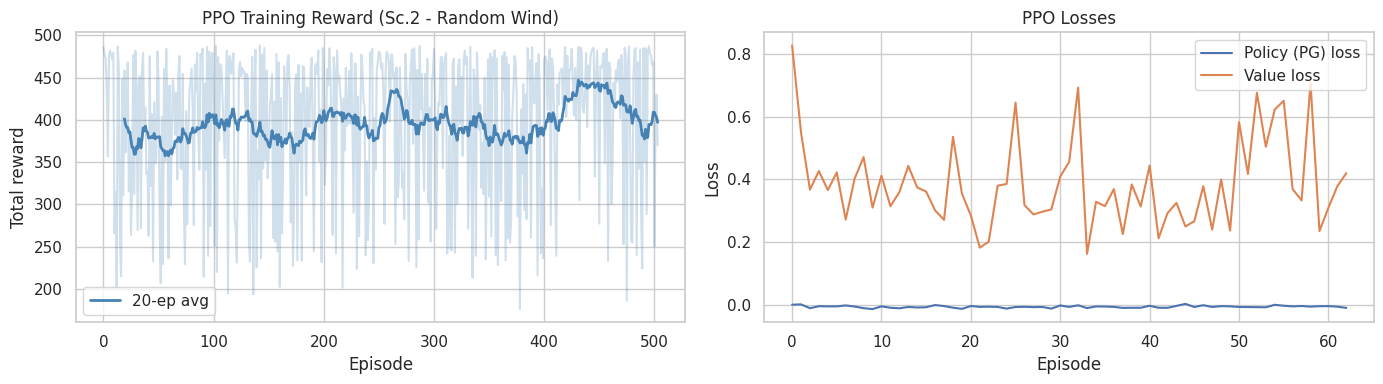

In [11]:
WINDOW   = 20
smoothed = np.convolve(episode_rewards, np.ones(WINDOW) / WINDOW, mode="valid")

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

ax = axes[0]
ax.plot(episode_rewards, alpha=0.25, color="steelblue")
ax.plot(np.arange(WINDOW - 1, len(episode_rewards)), smoothed,
        color="steelblue", linewidth=2, label=f"{WINDOW}-ep avg")
ax.set_xlabel("Episode")
ax.set_ylabel("Total reward")
ax.set_title("PPO Training Reward (Sc.2 - Random Wind)")
ax.legend()

ax = axes[1]
ax.plot(loss_log["pg"],  label="Policy (PG) loss")
ax.plot(loss_log["vf"],  label="Value loss")
ax.set_xlabel("Episode")
ax.set_ylabel("Loss")
ax.set_title("PPO Losses")
ax.legend()

plt.tight_layout()
plt.show()

## Evaluation: Greedy Policy Rollout

Run the trained policy deterministically (actor mean only, no sampling noise).

In [12]:
def evaluate_policy(n_episodes: int = 5, greedy: bool = True, seed_offset: int = 9000):
    """Return episode reward list and a DataFrame of the first episode's trajectory."""
    policy.eval()
    rewards   = []
    eval_rows = []

    with torch.no_grad():
        for ep in range(n_episodes):
            obs_dict = env_reset(seed_offset + ep, WIND_OPTS)
            done, total_r, step = False, 0.0, 0

            while not done:
                obs_np   = flatten_obs(obs_dict)
                obs_t    = torch.tensor(obs_np, dtype=torch.float32,
                                        device=DEVICE).unsqueeze(0)
                if greedy:
                    features = policy.actor_backbone(obs_t)
                    action_t = policy.actor_mean(features)
                else:
                    action_t = policy.act(obs_t)[0]
                # Clip to the actual action space bounds (not a hardcoded constant)
                action_np    = np.clip(
                    action_t.squeeze(0).cpu().numpy(),
                    env.action_space["yaw"].low,
                    env.action_space["yaw"].high,
                )
                joint_action = {"yaw": action_np}

                obs_dict, reward, termination, truncation, info = env.step(joint_action)
                r        = float(reward[0]) if hasattr(reward, "__len__") else float(reward)
                total_r += r

                if ep == 0:
                    eval_rows.append({
                        "step":   step,
                        "reward": r,
                        **{f"yaw_{i}":   obs_dict["yaw"][i]   for i in range(N_TURBINES)},
                        **{f"power_{i}": info["power"][i]     for i in range(N_TURBINES)},
                    })
                step += 1
                done = termination or truncation

            rewards.append(total_r)

    policy.train()
    return rewards, pd.DataFrame(eval_rows)


eval_rewards, eval_df = evaluate_policy(n_episodes=5)
print(f"Eval total rewards: {[f'{r:.2f}' for r in eval_rewards]}")
print(f"Mean +- std:  {np.mean(eval_rewards):.2f} +- {np.std(eval_rewards):.2f}")

Eval total rewards: ['216.45', '486.08', '475.10', '391.25', '488.63']
Mean +- std:  411.50 +- 103.93


## Yaw Angles and Power Over a Representative Episode

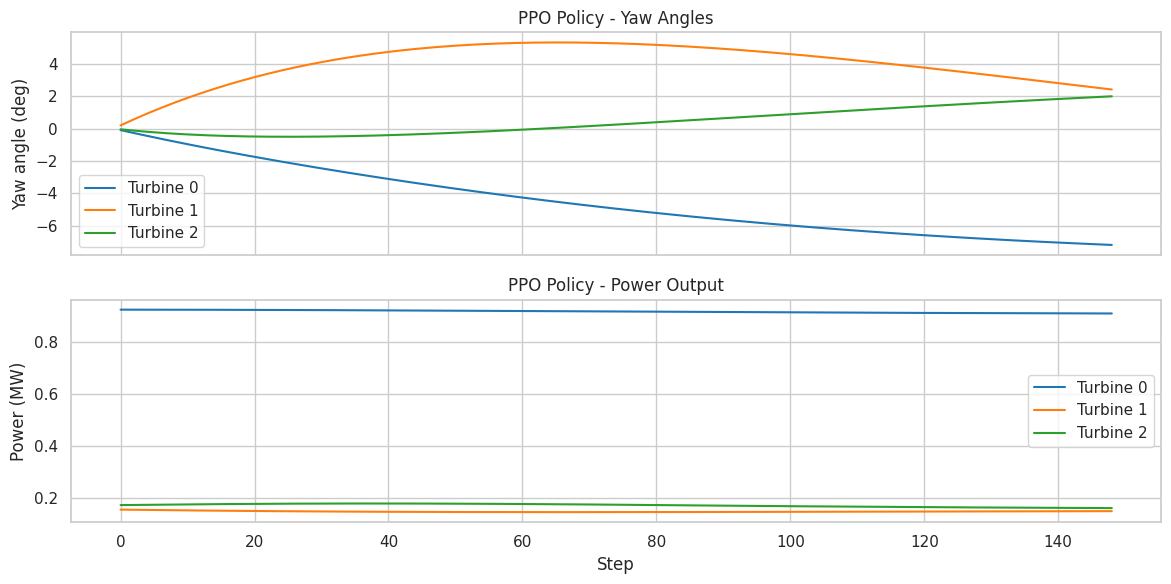

In [13]:
colors = sns.color_palette("tab10", N_TURBINES)
fig, axes = plt.subplots(2, 1, figsize=(12, 6), sharex=True)

ax = axes[0]
for i in range(N_TURBINES):
    ax.plot(eval_df["step"], eval_df[f"yaw_{i}"],
            color=colors[i], label=f"Turbine {i}")
ax.set_ylabel("Yaw angle (deg)")
ax.set_title("PPO Policy - Yaw Angles")
ax.legend()

ax = axes[1]
for i in range(N_TURBINES):
    ax.plot(eval_df["step"], eval_df[f"power_{i}"],
            color=colors[i], label=f"Turbine {i}")
ax.set_xlabel("Step")
ax.set_ylabel("Power (MW)")
ax.set_title("PPO Policy - Power Output")
ax.legend()

plt.tight_layout()
plt.show()

In [14]:

for i in range(N_TURBINES):
    print(f"{i}: {eval_df['step'].iloc[0]}, {eval_df[f'yaw_{i}'].iloc[0]}")

0: 0, -0.09362800419330597
1: 0, 0.19613893330097198
2: 0, -0.04515300691127777


In [15]:
# print the last step's yaw angles for each turbine
n_turbines = len([c for c in eval_df.columns if c.startswith("yaw_")])
for i in range(n_turbines):
    print(f"{i}: {eval_df['step'].iloc[-1]}, {eval_df[f'yaw_{i}'].iloc[-1]}")

0: 148, -7.192533016204834
1: 148, 2.4151291847229004
2: 148, 1.9937652349472046


## Final Comparison

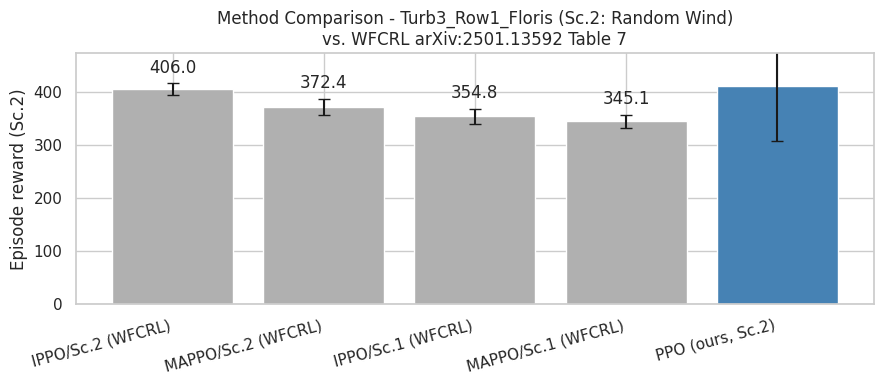


Summary (Sc.2 episode reward):
  Method                         Mean     Std
  IPPO/Sc.2 (WFCRL)             406.0    10.5
  MAPPO/Sc.2 (WFCRL)            372.4    15.5
  IPPO/Sc.1 (WFCRL)             354.8    14.4
  MAPPO/Sc.1 (WFCRL)            345.1    12.6
  PPO (ours, Sc.2)              411.5   103.9 <-- ours


In [ ]:
# WFCRL Table 7 reference results (Turb3_Row1_Floris, FLORIS, 200k steps, eval on Sc.2)
WFCRL_BASELINES = {
    "IPPO/Sc.2 (WFCRL)":  (406.0, 10.5),
    "MAPPO/Sc.2 (WFCRL)": (372.4, 15.5),
    "IPPO/Sc.1 (WFCRL)":  (354.8, 14.4),
    "MAPPO/Sc.1 (WFCRL)": (345.1, 12.6),
}

our_results = {
    "PPO (ours, Sc.2)": (np.mean(eval_rewards), np.std(eval_rewards)),
}

all_labels = list(WFCRL_BASELINES.keys()) + list(our_results.keys())
all_means  = [v[0] for v in WFCRL_BASELINES.values()] + [v[0] for v in our_results.values()]
all_errs   = [v[1] for v in WFCRL_BASELINES.values()] + [v[1] for v in our_results.values()]
colors     = ["#b0b0b0"] * len(WFCRL_BASELINES) + ["steelblue"]

fig, ax = plt.subplots(figsize=(9, 4))
bars = ax.bar(all_labels, all_means, yerr=all_errs, capsize=4, color=colors)
ax.bar_label(bars, labels=[f"{m:.1f}" for m in all_means], padding=5)
ax.set_ylabel("Episode reward (Sc.2)")
ax.set_title("Method Comparison - Turb3_Row1_Floris (Sc.2: Random Wind)\nvs. WFCRL arXiv:2501.13592 Table 7")
ax.set_ylim(200, max(all_means) * 1.25)
plt.xticks(rotation=15, ha="right")
plt.tight_layout()
plt.show()

print("\nSummary (Sc.2 episode reward):")
print(f"  {'Method':<26s}  {'Mean':>7s}  {'Std':>6s}")
for label, (mean, std) in {**WFCRL_BASELINES, **our_results}.items():
    marker = " <-- ours" if "ours" in label else ""
    print(f"  {label:<26s}  {mean:>7.1f}  {std:>6.1f}{marker}")